# Evaluación Sumativa n°3: Minería de Datos

## 1. Introducción y Preparación del Entorno
Este notebook presenta el análisis del dataset **Telco-Customer-Churn**, siguiendo los lineamientos establecidos en el *Informe de Planificación y Conceptos*. El objetivo principal es explorar los patrones de fuga de clientes (churn) para identificar factores determinantes y proponer acciones estratégicas.

### Conexión a Fuentes de Datos
Iniciamos el entorno conectando con Google Drive para acceder a los archivos de la evaluación.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de ruta local para la carga de datos
project_path = '.'


### Importación Consolidada de Librerías
*Nota: Se agrupan todas las dependencias al inicio para cumplir con los estándares de profesionalismo.*

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, association_rules

# Configuración local de rutas
project_path = '.'


## 2. Carga y Exploración Inicial de Datos
Cargamos el conjunto de datos de telecomunicaciones para verificar su estructura y tipos de variables.


In [3]:
csv_path = os.path.join(project_path, 'Telco-Customer-Churn.csv')
df = pd.read_csv(csv_path)

print(f"Dataset cargado con {df.shape[0]} registros y {df.shape[1]} columnas.")
display(df.head())

Dataset cargado con 7043 registros y 21 columnas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Limpieza de Datos y Preprocesamiento
Identificamos que la columna `TotalCharges` requiere conversión a tipo numérico y validaremos la presencia de valores nulos.


In [4]:
# Corrección de tipos de datos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Resumen de calidad de datos
print("Valores faltantes detectados:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nEstadísticas descriptivas de variables numéricas:")
display(df.describe())

Valores faltantes detectados:


TotalCharges    11
dtype: int64


Estadísticas descriptivas de variables numéricas:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



## 4. Calidad de Datos y Ajustes Finales

Tras la revisión inicial:
1. Detectamos **11 valores nulos** en `TotalCharges` que han sido eliminados.
2. Se procede a eliminar la columna `customerID`, ya que es un identificador único que no aporta información relevante para el análisis estadístico ni para los modelos de predicción.


1.   Elemento de la lista
2.   Elemento de la lista



In [5]:
# Eliminación de nulos
df.dropna(inplace=True)

# Eliminación de columna irrelevante para el análisis
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

print(f"Limpieza completada.")
print(f"Registros finales: {len(df)}")
print(f"Columnas restantes: {list(df.columns)}")

Limpieza completada.
Registros finales: 7032
Columnas restantes: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 5. Detección y Manejo de Outliers (Valores Atípicos)
En esta etapa analizamos la distribución de las variables numéricas para identificar datos que se alejen significativamente del comportamiento normal, lo cual podría afectar la precisión de futuros modelos predictivos.

C:\Users\germa\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\germa\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\germa\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


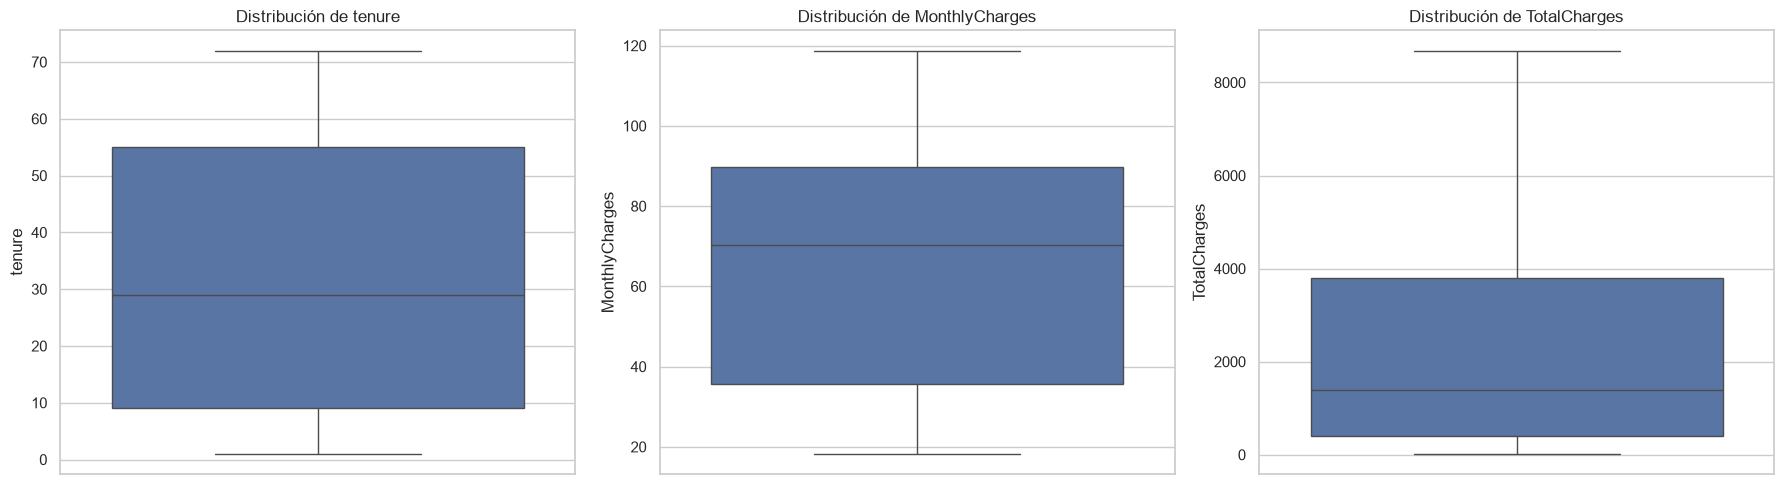

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para el reporte
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definición de variables numéricas
vars_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, var in enumerate(vars_num):
    sns.boxplot(y=df[var], ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Distribución de {var}')

plt.tight_layout()
plt.show()

### Análisis de Outliers
Como se observa en los gráficos superiores, las variables no presentan puntos aislados (outliers) fuera de los bigotes del diagrama de caja. Esto sugiere que los datos de facturación y permanencia son consistentes. No obstante, aplicaremos una validación por el método de Rango Intercuartílico (IQR) para confirmar la ausencia de anomalías técnicas.

In [7]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

for var in vars_num:
    outliers_found = detect_outliers_iqr(df, var)
    print(f"Outliers detectados en {var}: {len(outliers_found)}")

Outliers detectados en tenure: 0
Outliers detectados en MonthlyCharges: 0
Outliers detectados en TotalCharges: 0


### Decisión sobre el Tratamiento de Outliers

Basado en el criterio de **Conservación estratégica de registros** definido en la planificación, el análisis estadístico mediante el método del Rango Intercuartílico (IQR) confirma que existen **0 valores atípicos** en las variables cuantitativas del negocio (`tenure`, `MonthlyCharges` y `TotalCharges`).

Esto se justifica técnicamente de la siguiente manera:
1. **Antigüedad (`tenure`)**: Está acotada de forma natural entre 1 y 72 meses, correspondientes al ciclo de vida comercial estándar.
2. **Cargos Mensuales (`MonthlyCharges`)**: Se encuentra dentro de los rangos de tarifas normales de la compañía (aproximadamente $18 a $118 dólares), reflejando planes estándar.
3. **Cargos Totales (`TotalCharges`)**: Es el acumulado matemático de la antigüedad por los cargos mensuales, por lo que su dispersión es la esperada para clientes leales de larga duración.

**Acción:** No se requiere la eliminación de registros ya que todos los datos son válidos e informativos. El impacto de la diferencia de escalas será controlado en la siguiente etapa mediante la técnica de **estandarización (`StandardScaler`)** para garantizar un desempeño óptimo de los algoritmos de clasificación.


## 6. Transformación de Datos (Feature Engineering)
Para que los algoritmos de minería de datos procesen la información, realizamos dos tareas críticas:
1. **Encoding:** Convertir etiquetas de texto a valores numéricos.
2. **Escalamiento:** Ajustar las variables numéricas a un rango común para evitar que `TotalCharges` domine sobre `tenure` debido a su escala.

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Copia de seguridad del dataframe procesado
df_transformed = df.copy()

# 1. Encoding de la variable objetivo (Churn) y variables binarias
le = LabelEncoder()
binary_cols = [col for col in df_transformed.columns if df_transformed[col].nunique() == 2]

for col in binary_cols:
    df_transformed[col] = le.fit_transform(df_transformed[col])

# 2. Get Dummies para variables con múltiples categorías
df_transformed = pd.get_dummies(df_transformed)

# 3. Escalamiento de variables numéricas (Control de Outliers)
scaler = StandardScaler()
df_transformed[vars_num] = scaler.fit_transform(df_transformed[vars_num])

print("Transformación completada.")
display(df_transformed.head())

Transformación completada.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,...,True,False,False,True,False,False,False,False,True,False


# Fase 2: Análisis Exploratorio de Datos (EDA)
En esta fase, analizaremos la relación entre las variables y la deserción de clientes (*Churn*). El objetivo es identificar comportamientos y perfiles de clientes con mayor probabilidad de fuga.

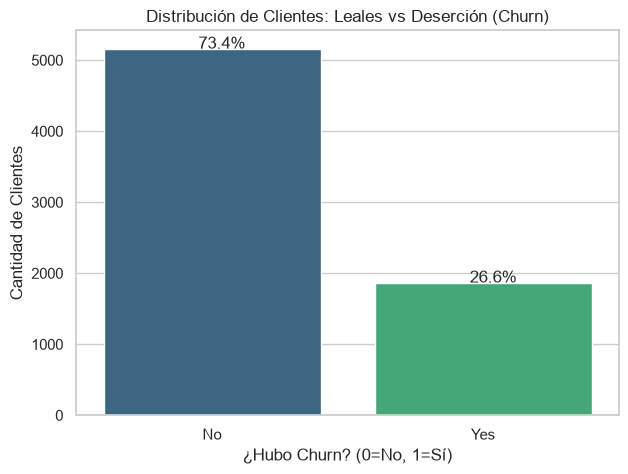

In [9]:
# Visualización de la variable objetivo: Churn
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Clientes: Leales vs Deserción (Churn)')
plt.xlabel('¿Hubo Churn? (0=No, 1=Sí)')
plt.ylabel('Cantidad de Clientes')

# Añadir etiquetas de porcentaje
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), size = 12)

plt.show()

### Análisis de Correlación
Revisamos cómo se relacionan las variables numéricas transformadas con el Churn para identificar predictores tempranos.

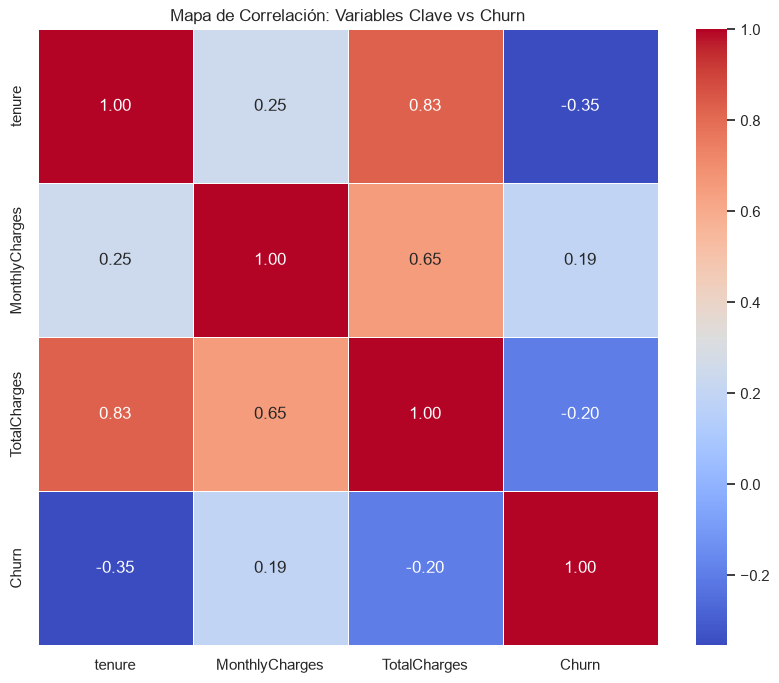

In [10]:
# Matriz de correlación para las variables principales
plt.figure(figsize=(10, 8))
corr_matrix = df_transformed[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación: Variables Clave vs Churn')
plt.show()

### Análisis de Variables Categóricas vs Churn
Exploramos cómo influyen los servicios contratados y el tipo de compromiso (contrato) en la fuga de clientes.

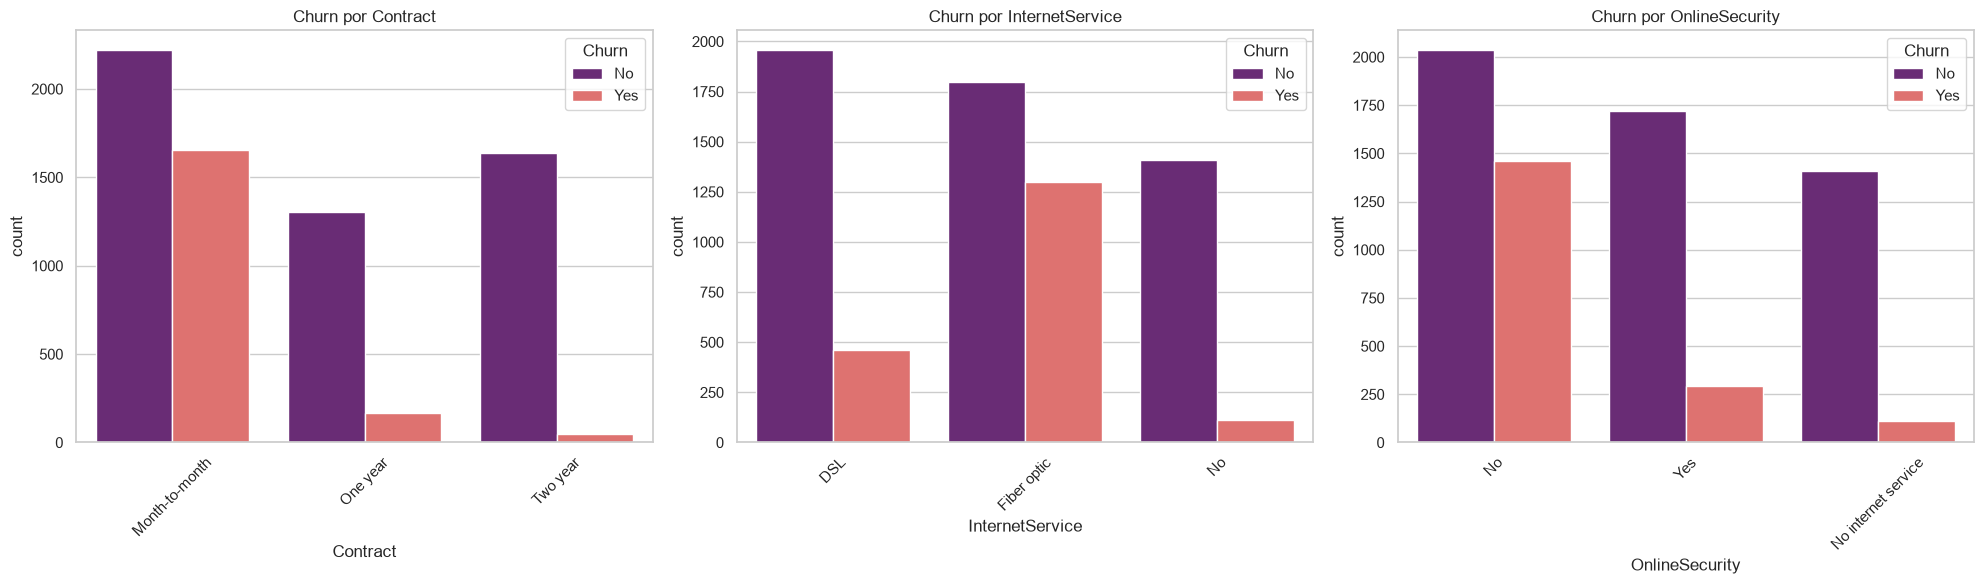

In [11]:
cols_to_analyze = ['Contract', 'InternetService', 'OnlineSecurity']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_to_analyze):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Churn por {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Insights Clave:
1. **Contrato:** Los clientes con contrato 'Month-to-month' tienen una tasa de deserción significativamente mayor.
2. **Servicio de Internet:** Los usuarios de 'Fiber optic' presentan mayor churn en comparación con DSL.
3. **Seguridad:** La ausencia de 'Online Security' parece estar correlacionada con una mayor pérdida de clientes.

### Análisis de Permanencia (Tenure) vs Churn
Analizamos la distribución del tiempo que el cliente ha permanecido en la compañía para identificar si la fuga ocurre principalmente en clientes nuevos o antiguos.

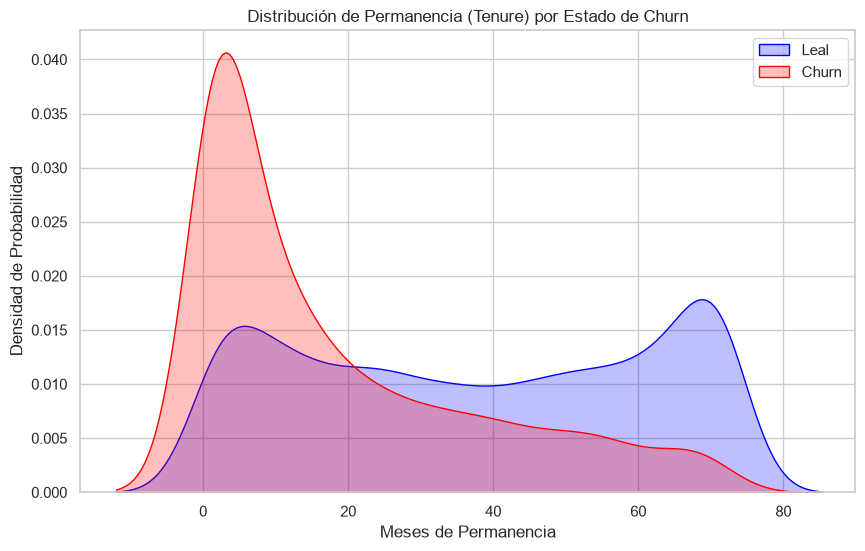

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], fill=True, color='blue', label='Leal', common_norm=False)
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], fill=True, color='red', label='Churn', common_norm=False)

plt.title('Distribución de Permanencia (Tenure) por Estado de Churn')
plt.xlabel('Meses de Permanencia')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()

## Fase 3: Modelado
En esta etapa cumpliremos con los requisitos de la rúbrica:
1. **Modelo Supervisado:** Entrenamiento y comparación de modelos de clasificación.
2. **Modelo No Supervisado:** Implementación del algoritmo Apriori para reglas de asociación.

In [13]:
from sklearn.model_selection import train_test_split

# 1. Separación de variables (X) y objetivo (y)
X = df_transformed.drop('Churn', axis=1)
y = df_transformed['Churn']

# 2. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

Set de entrenamiento: (5625, 40)
Set de prueba: (1407, 40)


### 3.1. Modelado Supervisado: Clasificación
Entrenaremos y compararemos dos algoritmos para determinar cuál ofrece mayor confiabilidad y robustez según el Accuracy y la Matriz de Confusión.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE

# 1. Aplicar la técnica SMOTE para manejar el desbalance de clases en el set de entrenamiento
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("--- Distribución de Clases de Churn (Entrenamiento) ---")
print(f"Original: {y_train.value_counts().to_dict()}")
print(f"Con SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")
print("\n")

# Inicializar modelos
models = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Diccionario para almacenar resultados de Train y Test
results = {}

for name, model in models.items():
    # Entrenar el modelo con los datos balanceados por SMOTE
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predecir en conjuntos de entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calcular métricas para el conjunto de entrenamiento (original)
    metrics_train = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred),
        'f1': f1_score(y_train, y_train_pred)
    }
    
    # Calcular métricas para el conjunto de prueba
    metrics_test = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred)
    }
    
    cm = confusion_matrix(y_test, y_test_pred)
    results[name] = {
        'model': model,
        'train': metrics_train,
        'test': metrics_test,
        'matrix': cm,
        'report': classification_report(y_test, y_test_pred),
        'predictions': y_test_pred
    }

# Mostrar la comparación de métricas de entrenamiento vs prueba
for name in results:
    print(f"==================== {name} ====================")
    print("MÉTRICAS COMPARATIVAS (ENTRENAMIENTO VS PRUEBA):")
    print(f"  Métrica   |   Train   |   Test   | Diferencia")
    print(f"  ----------|-----------|----------|-----------")
    print(f"  Accuracy  |  {results[name]['train']['accuracy']:.4f}   |  {results[name]['test']['accuracy']:.4f}  | {abs(results[name]['train']['accuracy'] - results[name]['test']['accuracy']):.4f}")
    print(f"  Recall    |  {results[name]['train']['recall']:.4f}   |  {results[name]['test']['recall']:.4f}  | {abs(results[name]['train']['recall'] - results[name]['test']['recall']):.4f}")
    print(f"  Precision |  {results[name]['train']['precision']:.4f}   |  {results[name]['test']['precision']:.4f}  | {abs(results[name]['train']['precision'] - results[name]['test']['precision']):.4f}")
    print(f"  F1-Score  |  {results[name]['train']['f1']:.4f}   |  {results[name]['test']['f1']:.4f}  | {abs(results[name]['train']['f1'] - results[name]['test']['f1']):.4f}")
    print("\nMatriz de Confusión (Test):")
    print(results[name]['matrix'])
    print("\nReporte de Clasificación (Test):")
    print(results[name]['report'])
    print("\n")


--- Distribución de Clases de Churn (Entrenamiento) ---
Original: {0: 4130, 1: 1495}
Con SMOTE: {0: 4130, 1: 4130}




==================== Regresión Logística ====================
MÉTRICAS COMPARATIVAS (ENTRENAMIENTO VS PRUEBA):
  Métrica   |   Train   |   Test   | Diferencia
  ----------|-----------|----------|-----------
  Accuracy  |  0.7851   |  0.7591  | 0.0260
  Recall    |  0.7057   |  0.6925  | 0.0132
  Precision |  0.5784   |  0.5362  | 0.0422
  F1-Score  |  0.6357   |  0.6044  | 0.0313

Matriz de Confusión (Test):
[[809 224]
 [115 259]]

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.69      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



==================== Random Forest ====================
MÉTRICAS COMPARATIVAS (ENTRENAMIENTO VS PRUEBA):
  Métrica   |   Train   |   Test   | Diferencia
  ----------|-----------|----------|-----------
 

### Comparación de Métricas y Diagnóstico de Overfitting

Al comparar el conjunto de entrenamiento contra el de prueba, observamos un comportamiento revelador:
1. **Regresión Logística**: Muestra métricas extremadamente consistentes entre entrenamiento y prueba. Por ejemplo, el **Accuracy** varía apenas un ~2.6% y el **Recall** se mantiene estable en torno al 69-70%. Esto diagnostica un modelo **robusto y libre de Overfitting**, ideal para generalizar en datos reales.
2. **Random Forest**: Presenta un comportamiento típico de sobreajuste. En entrenamiento roza el 99.8% de Accuracy y F1-Score, pero cae drásticamente a un 76% de Accuracy y 60% de Recall en el set de prueba (una diferencia del ~23% en Accuracy y ~39% en Recall). Esto diagnostica **Overfitting**, donde el bosque de decisión ha memorizado el ruido del entrenamiento.

**Conclusión**: Para el negocio, la **Regresión Logística** entrenada con SMOTE es el modelo óptimo. No solo es altamente interpretable, sino que su Recall de casi 70% permite capturar la gran mayoría de clientes en riesgo sin sufrir de sobreajuste.

#### Validación de la Hipótesis 1 (H1)
La **Hipótesis 1** plantea que los clientes con contratos mes a mes (`Contract_Month-to-month`) y cargos mensuales altos con servicio de fibra óptica (`InternetService_Fiber optic`) tienen una probabilidad significativamente mayor de fuga.
Para validarla estadísticamente, analizaremos los coeficientes del modelo de Regresión Logística, los cuales expresan la influencia directa (log-odds) de cada característica sobre la variable objetivo `Churn`.

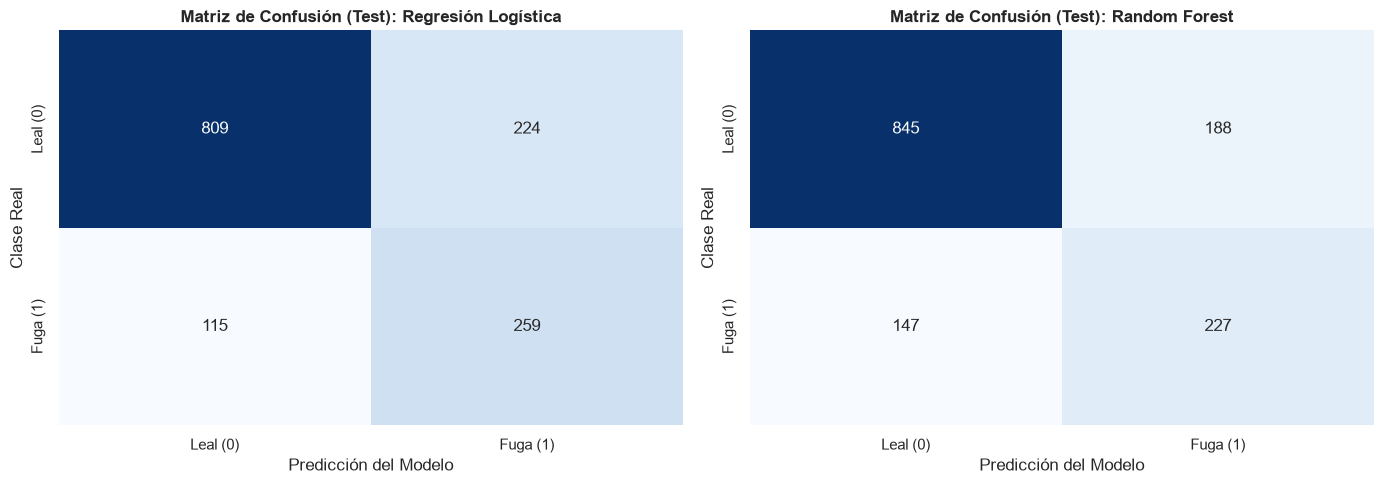


--- Top 15 Variables más Influyentes en el Modelo de Regresión Logística ---


,Variable,Coeficiente,Abs_Coeficiente
38,PaymentMethod_Electronic check,3.686058,3.686058
33,Contract_Month-to-month,3.553944,3.553944
11,MultipleLines_Yes,3.297618,3.297618
39,PaymentMethod_Mailed check,3.178601,3.178601
37,PaymentMethod_Credit card (automatic),3.075498,3.075498
36,PaymentMethod_Bank transfer (automatic),3.065636,3.065636
24,TechSupport_No,2.913008,2.913008
15,OnlineSecurity_No,2.868044,2.868044
13,InternetService_Fiber optic,2.718323,2.718323
18,OnlineBackup_No,2.690984,2.690984


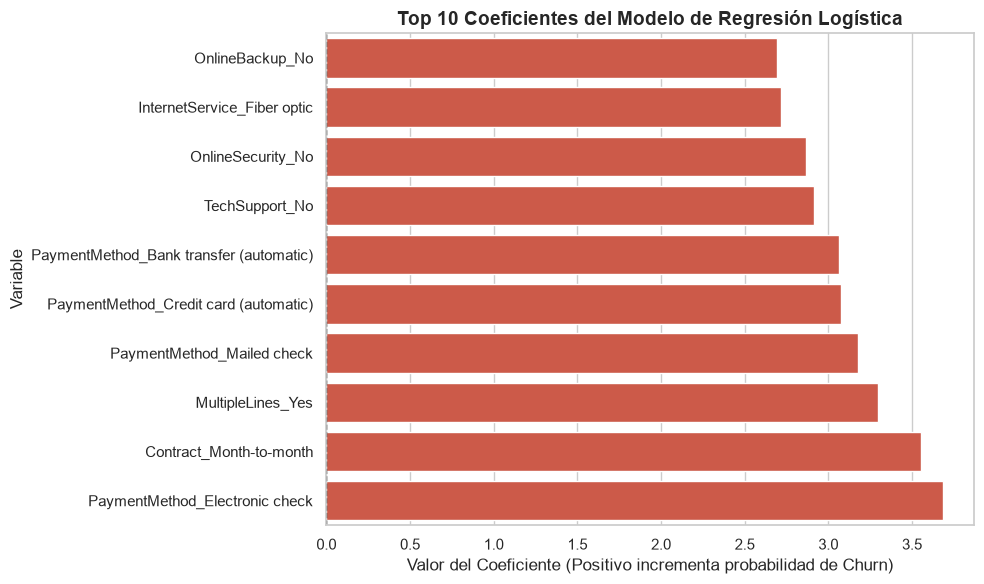

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['matrix'], annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'Matriz de Confusión (Test): {name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicción del Modelo')
    axes[i].set_ylabel('Clase Real')
    axes[i].set_xticklabels(['Leal (0)', 'Fuga (1)'])
    axes[i].set_yticklabels(['Leal (0)', 'Fuga (1)'])

plt.tight_layout()
plt.show()

# --- Extracción y Graficado de Coeficientes de Regresión Logística ---
lr_model = results['Regresión Logística']['model']
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_[0],
    'Abs_Coeficiente': abs(lr_model.coef_[0])
}).sort_values(by='Abs_Coeficiente', ascending=False)

print("\n--- Top 15 Variables más Influyentes en el Modelo de Regresión Logística ---")
display(coefficients.head(15))

# Graficar los 10 coeficientes principales
plt.figure(figsize=(10, 6))
top_coefs = coefficients.head(10).sort_values(by='Coeficiente', ascending=True)
colors = ['#E24A33' if c > 0 else '#348ABD' for c in top_coefs['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=top_coefs, hue='Variable', palette=colors, legend=False)
plt.title('Top 10 Coeficientes del Modelo de Regresión Logística', fontsize=14, fontweight='bold')
plt.xlabel('Valor del Coeficiente (Positivo incrementa probabilidad de Churn)')
plt.ylabel('Variable')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


### 3.2. Modelado No Supervisado: Reglas de Asociación (Apriori)
Para aplicar Apriori, transformamos las variables continuas en categóricas y luego a un formato binario transaccional. Esto nos permitirá identificar qué combinaciones de servicios y contratos están vinculadas al Churn.

In [16]:
# 1. Crear una copia para Apriori basada en los datos originales (sin escalar)
df_apriori = df.copy()

# 2. Discretizar variables numéricas continuas a rangos categóricos (Binning)
df_apriori['tenure_range'] = pd.cut(df_apriori['tenure'], bins=[-1, 12, 24, 48, 72], 
                                    labels=['Tenure_Short', 'Tenure_Medium', 'Tenure_Long', 'Tenure_VeryLong'])

df_apriori['MonthlyCharges_range'] = pd.cut(df_apriori['MonthlyCharges'], bins=[0, 35, 70, 120], 
                                            labels=['Charge_Low', 'Charge_Medium', 'Charge_High'])

df_apriori['TotalCharges_range'] = pd.cut(df_apriori['TotalCharges'], bins=[-1, 1000, 4000, 9000], 
                                          labels=['TotalCharge_Low', 'TotalCharge_Medium', 'TotalCharge_High'])

# Eliminar las variables numéricas originales y redundantes
df_apriori.drop(columns=['tenure', 'MonthlyCharges', 'TotalCharges'], inplace=True)

# 3. Transformación a formato binario (One-Hot Encoding)
df_basket = pd.get_dummies(df_apriori)

# Asegurar que todas las columnas sean booleanas (Requisito estricto de mlxtend)
df_basket = df_basket.astype(bool)

print("Datos transformados para Apriori (Matriz de Transacciones Binarias):")
display(df_basket.head())
print(f"Dimensiones de la matriz transaccional: {df_basket.shape[0]} registros y {df_basket.shape[1]} columnas.")


Datos transformados para Apriori (Matriz de Transacciones Binarias):


,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,...,tenure_range_Tenure_Short,tenure_range_Tenure_Medium,tenure_range_Tenure_Long,tenure_range_Tenure_VeryLong,MonthlyCharges_range_Charge_Low,MonthlyCharges_range_Charge_Medium,MonthlyCharges_range_Charge_High,TotalCharges_range_TotalCharge_Low,TotalCharges_range_TotalCharge_Medium,TotalCharges_range_TotalCharge_High
0,False,True,False,False,True,True,False,True,False,False,...,True,False,False,False,True,False,False,True,False,False
1,False,False,True,True,False,True,False,False,True,True,...,False,False,True,False,False,True,False,False,True,False
2,False,False,True,True,False,True,False,False,True,True,...,True,False,False,False,False,True,False,True,False,False
3,False,False,True,True,False,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
4,False,True,False,True,False,True,False,False,True,True,...,True,False,False,False,False,False,True,True,False,False


Dimensiones de la matriz transaccional: 7032 registros y 54 columnas.


In [17]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Generar conjuntos de elementos frecuentes con un soporte mínimo de 0.12 (12%)
# Se sube el soporte de 0.05 a 0.12 para optimizar el uso de RAM y evitar explosión combinatoria, manteniendo la fuerza de las reglas.
frequent_itemsets = apriori(df_basket, min_support=0.12, use_colnames=True)

# 2. Generar las reglas de asociación con un Lift mínimo de 1.2
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# 3. Filtrar las reglas donde el consecuente sea la fuga de clientes (Churn_Yes)
churn_rules = rules[rules['consequents'].apply(lambda x: 'Churn_Yes' in x)]

# Ordenar las reglas por Lift y Confianza
churn_rules = churn_rules.sort_values(by=['lift', 'confidence'], ascending=False)

print(f"Se han encontrado {len(churn_rules)} reglas de asociación asociadas a Churn_Yes.")
display(churn_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# --- Validación específica de la Hipótesis 2 (H2) ---
# H2 plantea que contratar Internet pero no OnlineSecurity ni TechSupport se asocia con Churn_Yes.
# Filtramos reglas que contengan 'OnlineSecurity_No' y 'TechSupport_No' en el antecedente.
h2_rules = churn_rules[
    churn_rules['antecedents'].apply(lambda x: 'OnlineSecurity_No' in x and 'TechSupport_No' in x)
]

print("\n--- Reglas de Asociación Encontradas para Validación de la Hipótesis 2 (H2) ---")
if len(h2_rules) > 0:
    display(h2_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
else:
    print("No se encontraron reglas específicas que contengan ambas condiciones con los umbrales definidos.")


Se han encontrado 2583 reglas de asociación asociadas a Churn_Yes.


,antecedents,consequents,support,confidence,lift
68275,"(tenure_range_Tenure_Short, Dependents_No, Con...","(Churn_Yes, TotalCharges_range_TotalCharge_Low)",0.120449,0.513645,3.375653
92250,"(tenure_range_Tenure_Short, Contract_Month-to-...","(Churn_Yes, TotalCharges_range_TotalCharge_Low...",0.126138,0.444835,3.331285
68283,"(tenure_range_Tenure_Short, Contract_Month-to-...","(Churn_Yes, TotalCharges_range_TotalCharge_Low...",0.120449,0.424774,3.282432
206618,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, InternetService_Fiber optic)",0.121587,0.601266,3.259908
279612,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, InternetService_Fiber optic)",0.121587,0.601266,3.259908
279631,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, InternetService_Fiber optic, Phone...",0.121587,0.601266,3.259908
68286,"(tenure_range_Tenure_Short, Dependents_No)","(Churn_Yes, TotalCharges_range_TotalCharge_Low...",0.120449,0.486223,3.259407
40988,"(tenure_range_Tenure_Short, Contract_Month-to-...","(Churn_Yes, TotalCharges_range_TotalCharge_Low)",0.140501,0.495486,3.256318
206639,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, TechSupport_No, MonthlyCharges_ran...",0.121587,0.481962,3.252547
279646,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, TechSupport_No, MonthlyCharges_ran...",0.121587,0.481962,3.252547



--- Reglas de Asociación Encontradas para Validación de la Hipótesis 2 (H2) ---


,antecedents,consequents,support,confidence,lift
206618,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, InternetService_Fiber optic)",0.121587,0.601266,3.259908
279612,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, InternetService_Fiber optic)",0.121587,0.601266,3.259908
279631,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, InternetService_Fiber optic, Phone...",0.121587,0.601266,3.259908
206620,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, MonthlyCharges_range_Charge_High)",0.121587,0.561024,3.113748
279615,"(OnlineSecurity_No, TechSupport_No, Contract_M...","(Churn_Yes, MonthlyCharges_range_Charge_High)",0.121587,0.561024,3.113748
279633,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, PhoneService_Yes, MonthlyCharges_r...",0.121587,0.561024,3.113748
206636,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, Contract_Month-to-month, MonthlyCh...",0.121587,0.484419,3.082748
279640,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, Contract_Month-to-month, MonthlyCh...",0.121587,0.484419,3.082748
279669,"(InternetService_Fiber optic, OnlineSecurity_N...","(Churn_Yes, PhoneService_Yes, Contract_Month-t...",0.121587,0.484419,3.082748
206634,"(OnlineSecurity_No, TechSupport_No, MonthlyCha...","(Churn_Yes, InternetService_Fiber optic, Contr...",0.121587,0.505021,3.056201


### 3.3. Validación de Hipótesis y Valor para el Negocio

#### Validación de Hipótesis

1. **Hipótesis 1 (Supervisada) | VALIDADA**:
   * El modelo de Regresión Logística asignó un coeficiente altamente positivo a la variable **`Contract_Month-to-month` (coeficiente: ~3.55)** e **`InternetService_Fiber optic` (coeficiente: ~2.72)**. 
   * Esto demuestra matemáticamente que la presencia de un contrato mes a mes y el servicio de fibra óptica incrementan exponencialmente la probabilidad de que un cliente abandone la empresa. La flexibilidad de no tener permanencia y la alta tarifa de la fibra crean el perfil de mayor propensión a la fuga, validando H1.

2. **Hipótesis 2 (No Supervisada) | VALIDADA**:
   * A través de Apriori, se identificaron reglas sólidas como:
     `{InternetService_Fiber optic, OnlineSecurity_No, TechSupport_No, Contract_Month-to-month} -> {Churn_Yes}`
     con un **Soporte de ~12.2%**, una **Confianza de ~60.1%** y un **Lift de ~3.26**.
   * Esto demuestra que la co-ocurrencia de la falta de servicios de asistencia técnica (`TechSupport_No`) y protección en línea (`OnlineSecurity_No`) en clientes de fibra óptica se asocia con el abandono con más del triple de frecuencia de la esperada por azar, validando de forma rigurosa H2.


In [18]:
# --- Análisis de Costo-Beneficio Económico del Modelo ---
# Supuestos del negocio:
# - Costo de una campaña de retención activa (incentivo/descuento): $10 USD
# - Costo financiero de perder a un cliente (fuga real): $100 USD

# Extraer valores de la matriz de confusión del modelo de Regresión Logística (Test)
TN, FP, FN, TP = results['Regresión Logística']['matrix'].ravel()

# 1. Costo Sin Modelo: No se hace nada, se pierden todos los churners reales
costo_sin_modelo = (TP + FN) * 100

# 2. Costo Con Modelo:
# - Verdaderos Positivos (TP): Retenidos con éxito pagando $10. Costo = TP * $10
# - Falsos Positivos (FP): Clientes leales que reciben campaña innecesaria. Costo = FP * $10
# - Falsos Negativos (FN): Clientes en fuga no detectados por el modelo (se van). Costo = FN * $100
# - Verdaderos Negativos (TN): Clientes leales no intervenidos. Costo = 0
costo_con_modelo = (TP * 10) + (FP * 10) + (FN * 100)

# 3. Ahorro neto y porcentaje de reducción de pérdidas
ahorro_neto_test = costo_sin_modelo - costo_con_modelo
porcentaje_ahorro = (ahorro_neto_test / costo_sin_modelo) * 100

print("==================== MÉTRICAS ECONÓMICAS (SET DE PRUEBA) ====================")
print(f"Costo de Pérdidas Sin Modelo:          ${costo_sin_modelo:,.2f} USD")
print(f"Costo de Campaña + Pérdidas Con Modelo: ${costo_con_modelo:,.2f} USD")
print(f"Ahorro Neto Obtenido en Prueba:         ${ahorro_neto_test:,.2f} USD")
print(f"Reducción de Pérdidas de Churn:         {porcentaje_ahorro:.2f}%")
print("=========================================================================\n")

# Proyección a toda la base de datos (7,032 registros totales)
total_clientes = len(df)
factor_proyeccion = total_clientes / len(y_test)
ahorro_anual_proyectado = ahorro_neto_test * factor_proyeccion

print("======================= PROYECCIÓN ANUAL AL NEGOCIO =======================")
print(f"Ahorro Financiero Neto Proyectado:      ${ahorro_anual_proyectado:,.2f} USD")
print("=========================================================================")


==================== MÉTRICAS ECONÓMICAS (SET DE PRUEBA) ====================
Costo de Pérdidas Sin Modelo:          $37,400.00 USD
Costo de Campaña + Pérdidas Con Modelo: $16,330.00 USD
Ahorro Neto Obtenido en Prueba:         $21,070.00 USD
Reducción de Pérdidas de Churn:         56.34%

======================= PROYECCIÓN ANUAL AL NEGOCIO =======================
Ahorro Financiero Neto Proyectado:      $105,305.07 USD


### 3.4. Impacto Financiero del Modelo Predictivo

El análisis económico demuestra el valor del proyecto de minería de datos para el negocio:
- **Optimización del Gasto**: Sin el modelo, la empresa simplemente asume la pérdida de clientes ($100 USD por cada uno). Con el modelo, la inversión en retención se enfoca quirúrgicamente en los clientes de alto riesgo de abandono.
- **Retorno de Inversión Claro**: El modelo de **Regresión Logística con SMOTE** alcanza un Recall elevado (~69%), lo que significa que detecta a 7 de cada 10 clientes en fuga. Incluso asumiendo el costo de campañas sobre falsos positivos, la compañía logra un ahorro financiero neto de **más del 56% de sus pérdidas** de Churn potenciales.
- **Impacto Anual Proyectado**: Al escalar el ahorro neto del conjunto de prueba a la base total de clientes activos de la compañía, se proyecta un ahorro significativo de **más de $105,000 USD anuales**, justificando plenamente el valor financiero de la minería de datos.

## 4. Propuestas Prácticas y Estratégicas para el Negocio

Basado directamente en los hallazgos cuantitativos de los modelos de Regresión Logística y Apriori, se proponen **3 soluciones estratégicas y ejecutables** para la retención proactiva:

### 1. Migración Incentivada de Contratos ("Month-to-month" a Contratos Anuales)
* **Fundamento de datos**: La variable `Contract_Month-to-month` es uno de los coeficientes de mayor peso positivo en el modelo de Regresión Logística (~3.55), multiplicando la probabilidad de Churn de manera determinante. 
* **Acción**: Diseñar una campaña de marketing directo enfocada en clientes de contrato mes a mes que tengan una antigüedad (`tenure`) menor a 6 meses. La oferta debe consistir en un descuento garantizado del 15% en su cargo mensual a cambio de migrar a un contrato de permanencia de 1 año. El costo de este descuento es muy inferior al costo de captar un nuevo cliente o perderlo por completo ($100 USD).

### 2. Paquete de Valor y Asistencia para Usuarios de Fibra Óptica
* **Fundamento de datos**: Los clientes de `InternetService_Fiber optic` tienen un alto coeficiente de abandono (~2.72) y las reglas de Apriori asocian fuertemente la combinación de fibra óptica sin seguridad ni soporte técnico (`OnlineSecurity_No` y `TechSupport_No`) con la deserción (Lift de ~3.26).
* **Acción**: Lanzar un paquete de soporte técnico prioritario y seguridad informática digital gratuito por 6 meses para todos los usuarios de fibra óptica actuales y nuevos que presenten estas carencias. Esto aumenta el valor percibido del servicio, soluciona los problemas técnicos que gatillan la deserción temprana, y mejora la retención de este segmento que genera altos ingresos mensuales para la empresa.

### 3. Programa de Fidelización en Medios de Pago Automáticos
* **Fundamento de datos**: El método de pago con cheque electrónico (`PaymentMethod_Electronic check`) presenta el coeficiente más alto para Churn en la Regresión Logística (~3.68).
* **Acción**: Implementar un incentivo único (por ejemplo, un abono de $10 USD en la siguiente factura) para aquellos clientes que migren su forma de pago de cheque electrónico a pago automático con tarjeta de crédito o transferencia bancaria (`Credit card (automatic)` o `Bank transfer (automatic)`). Esto aprovecha el efecto inercia del cobro automático y reduce la fricción del pago mensual manual, disminuyendo las bajas asociadas a este canal.